In [33]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [34]:
df = pd.read_csv("student_lifestyle_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (2000, 8)


,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   GPA                              2000 non-null   float64
 7   Stress_Level                     2000 non-null   str    
dtypes: float64(6), int64(1), str(1)
memory usage: 125.1 KB


In [36]:
df.describe(include='all')

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1029
mean,1000.500000,7.475800,1.990100,7.501250,2.704550,4.32830,3.115960,NaN
std,577.494589,1.423888,1.155855,1.460949,1.688514,2.51411,0.298674,NaN
min,1.000000,5.000000,0.000000,5.000000,0.000000,0.00000,2.240000,NaN
25%,500.750000,6.300000,1.000000,6.200000,1.200000,2.40000,2.900000,NaN
50%,1000.500000,7.400000,2.000000,7.500000,2.600000,4.10000,3.110000,NaN
75%,1500.250000,8.700000,3.000000,8.800000,4.100000,6.10000,3.330000,NaN


In [37]:
df.describe()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,7.475800,1.990100,7.501250,2.704550,4.32830,3.115960
std,577.494589,1.423888,1.155855,1.460949,1.688514,2.51411,0.298674
min,1.000000,5.000000,0.000000,5.000000,0.000000,0.00000,2.240000
25%,500.750000,6.300000,1.000000,6.200000,1.200000,2.40000,2.900000
50%,1000.500000,7.400000,2.000000,7.500000,2.600000,4.10000,3.110000
75%,1500.250000,8.700000,3.000000,8.800000,4.100000,6.10000,3.330000
max,2000.000000,10.000000,4.000000,10.000000,6.000000,13.00000,4.000000


In [38]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)

                                 Missing Count  Missing %
Student_ID                                   0        0.0
Study_Hours_Per_Day                          0        0.0
Extracurricular_Hours_Per_Day                0        0.0
Sleep_Hours_Per_Day                          0        0.0
Social_Hours_Per_Day                         0        0.0
Physical_Activity_Hours_Per_Day              0        0.0
GPA                                          0        0.0
Stress_Level                                 0        0.0


In [39]:
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

# Deletion: drop exact duplicate rows if any exist
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)


Duplicate rows: 0
Shape after dropping duplicates: (2000, 8)


In [40]:
df["Total_Productive_Hours"] = (
    df["Study_Hours_Per_Day"] +
    df["Extracurricular_Hours_Per_Day"]
)

df.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level,Total_Productive_Hours
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate,10.7
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low,8.8
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low,9.0
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate,8.6
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High,8.7


In [41]:
def sleep_category(x):
    if x < 6:
        return "Poor"
    elif x <= 8:
        return "Normal"
    else:
        return "Good"

df["Sleep_Category"] = df["Sleep_Hours_Per_Day"].apply(sleep_category)

df.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level,Total_Productive_Hours,Sleep_Category
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate,10.7,Good
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low,8.8,Normal
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low,9.0,Good
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate,8.6,Normal
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High,8.7,Normal


In [54]:
# Create a copy without Student_ID
eda_df = df.drop(columns=['Student_ID'])

eda_df.head()

,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level,Total_Productive_Hours,Sleep_Category
0,6.9,3.8,8.7,2.8,1.8,2.99,Moderate,10.7,Good
1,5.3,3.5,8.0,4.2,3.0,2.75,Low,8.8,Normal
2,5.1,3.9,9.2,1.2,4.6,2.67,Low,9.0,Good
3,6.5,2.1,7.2,1.7,6.5,2.88,Moderate,8.6,Normal
4,8.1,0.6,6.5,2.2,6.6,3.51,High,8.7,Normal


In [55]:
numeric_cols = eda_df.select_dtypes(include='number').columns

numeric_cols

Index(['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day',
       'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day',
       'Physical_Activity_Hours_Per_Day', 'GPA', 'Total_Productive_Hours'],
      dtype='str')

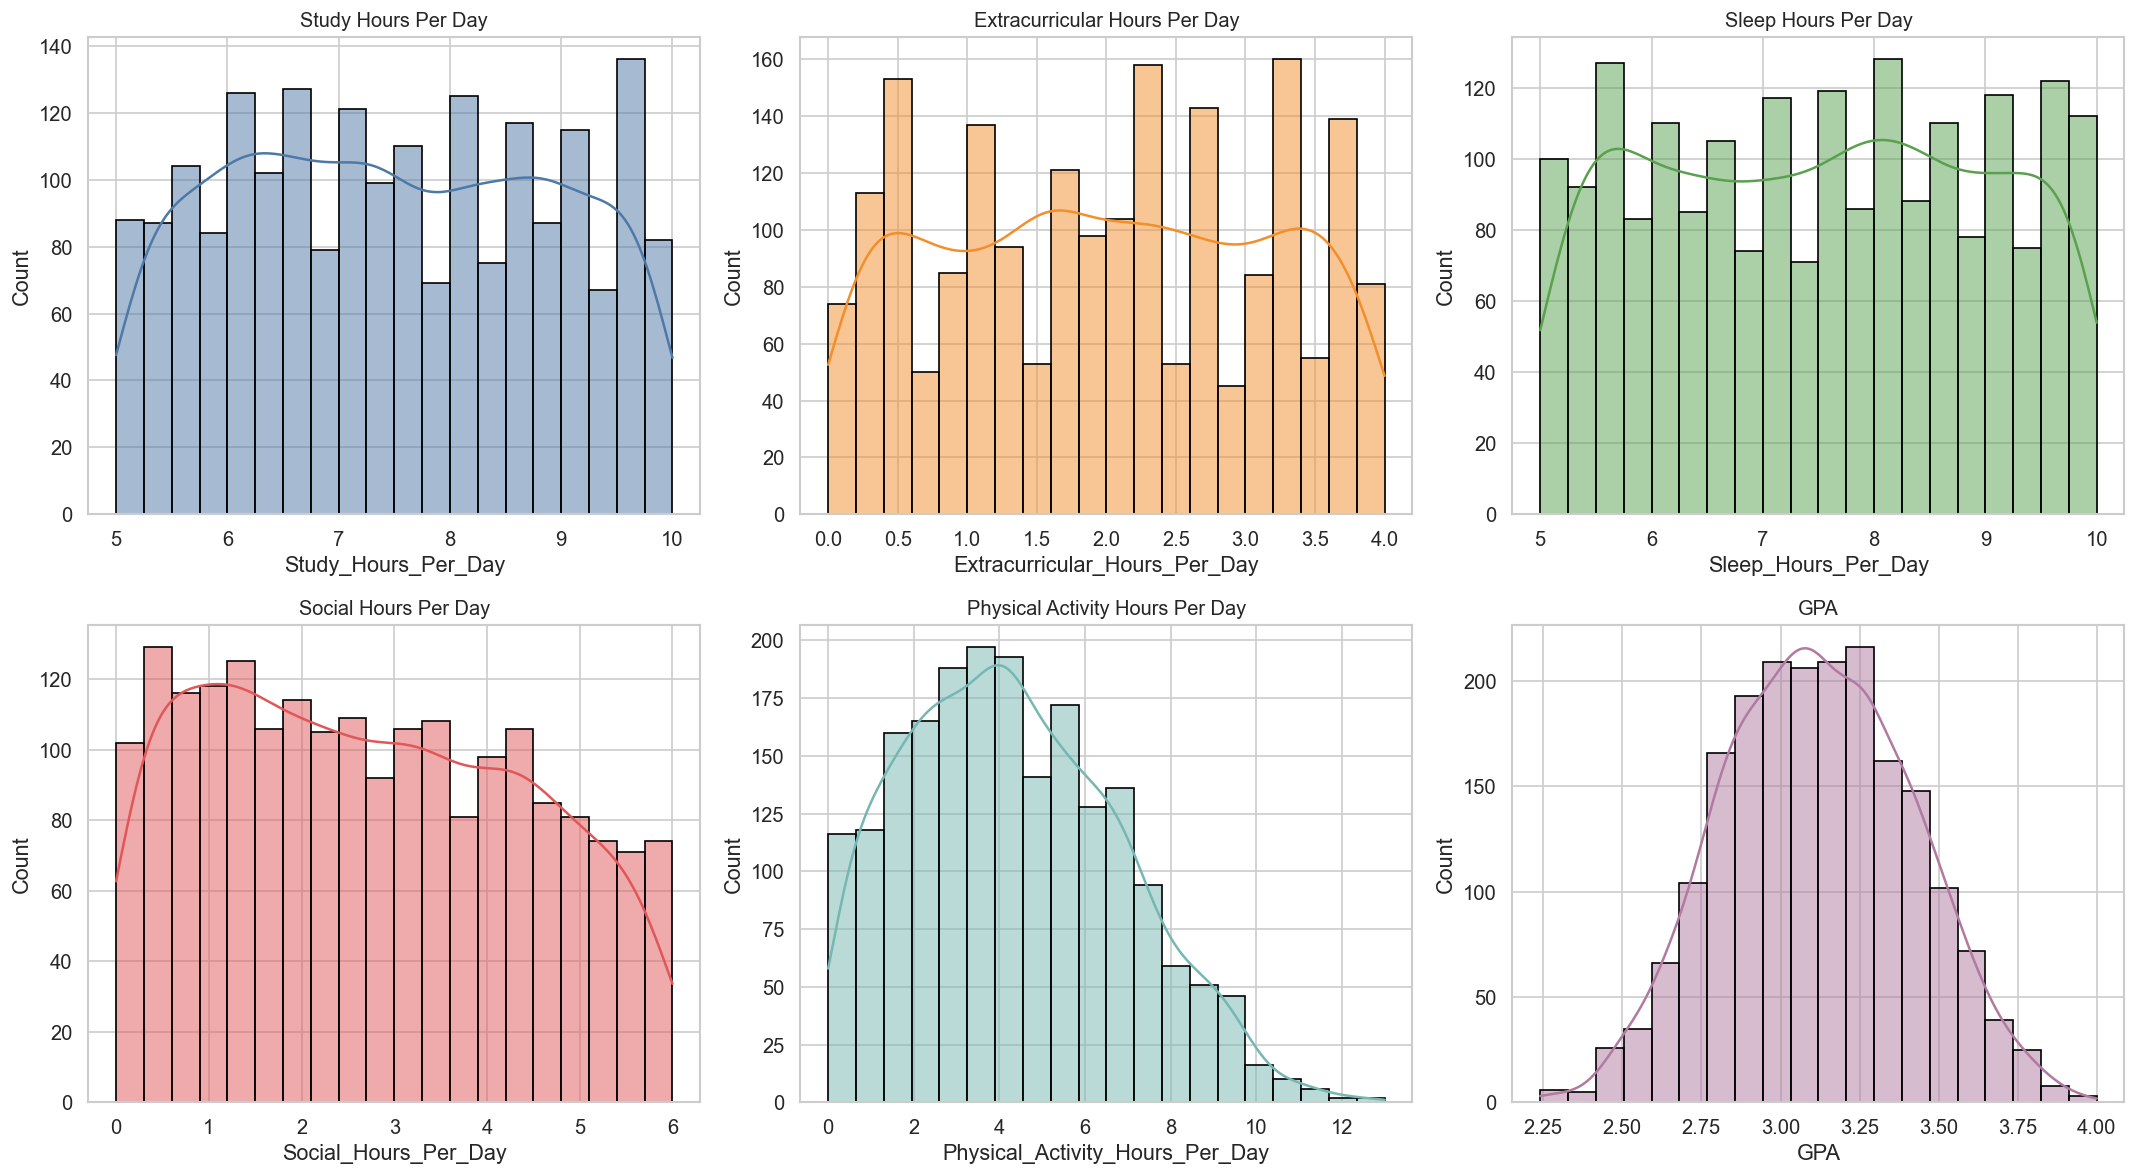

In [65]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))

colors = ['#4E79A7','#F28E2B','#59A14F','#E15759','#76B7B2','#B07AA1']

for ax, col, color in zip(axes.flatten(), numeric_cols[:-1], colors):
    sns.histplot(
        eda_df[col],
        kde=True,
        bins=20,
        color=color,
        edgecolor='black',
        ax=ax
    )

    ax.set_title(col.replace("_"," "), fontsize=12)

plt.tight_layout()
plt.show()

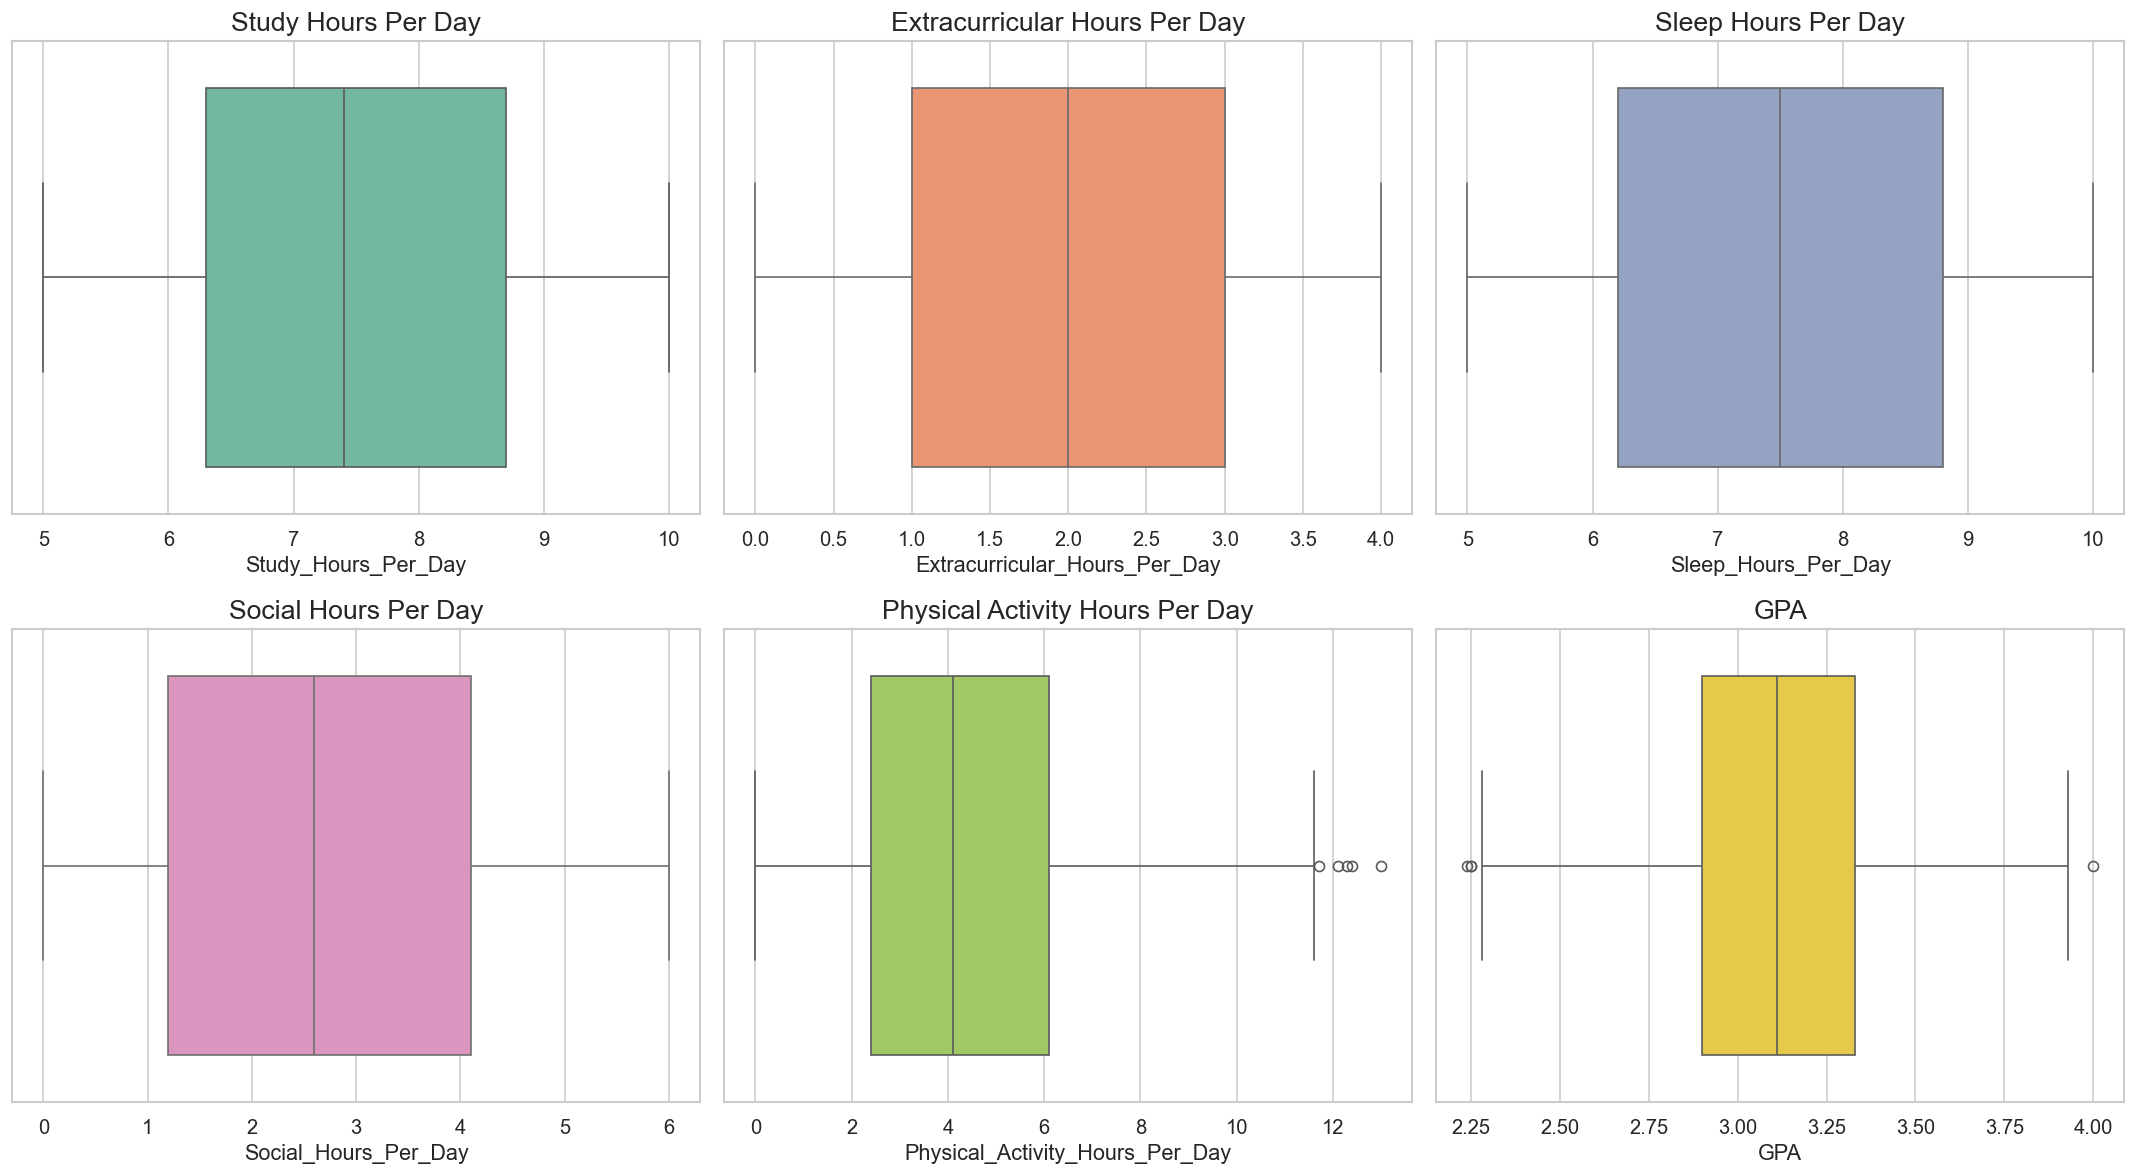

In [66]:
fig, axes = plt.subplots(2,3, figsize=(18,10))

palette = sns.color_palette("Set2",6)

for ax,col,color in zip(axes.flatten(), numeric_cols[:-1], palette):

    sns.boxplot(
        x=eda_df[col],
        color=color,
        ax=ax
    )

    ax.set_title(col.replace("_"," "))

plt.tight_layout()

plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_21268\3166892536.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


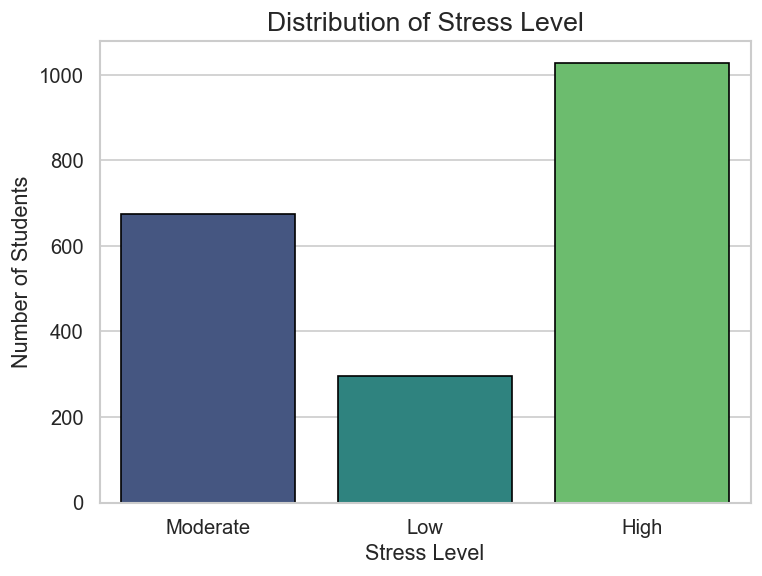

In [67]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=eda_df,
    x='Stress_Level',
    palette='viridis',
    edgecolor='black'
)

plt.title("Distribution of Stress Level", fontsize=16)

plt.xlabel("Stress Level")

plt.ylabel("Number of Students")

plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_21268\1293792802.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


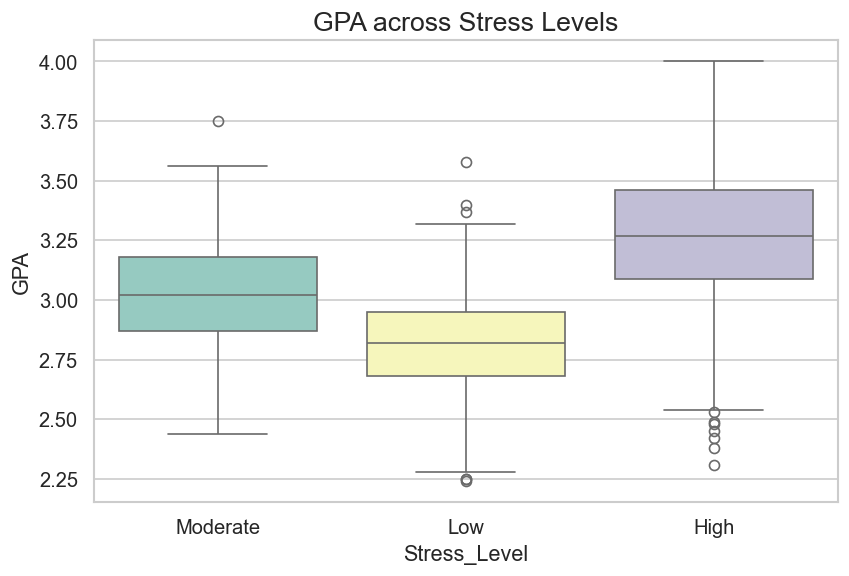

In [68]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda_df,
    x='Stress_Level',
    y='GPA',
    palette='Set3'
)

plt.title("GPA across Stress Levels", fontsize=16)

plt.show()

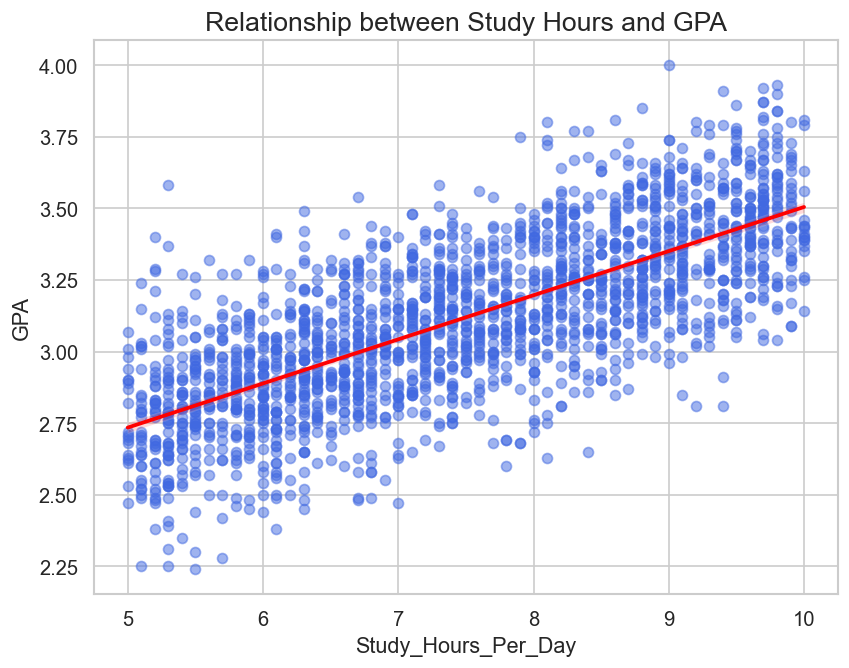

In [70]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=eda_df,
    x='Study_Hours_Per_Day',
    y='GPA',
    scatter_kws={'alpha':0.5,'color':'royalblue'},
    line_kws={'color':'red'}
)

plt.title("Relationship between Study Hours and GPA")

plt.show()

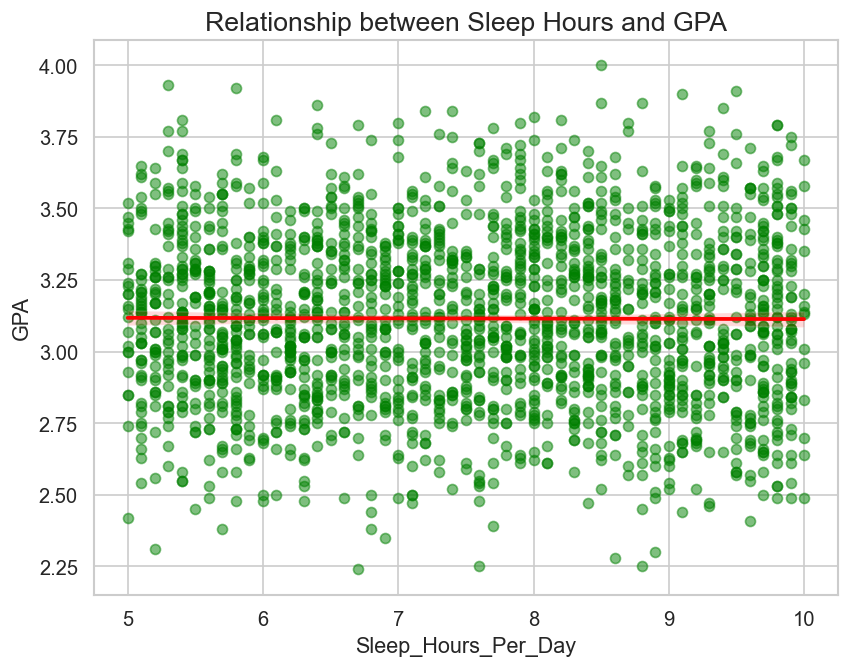

In [71]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=eda_df,
    x='Sleep_Hours_Per_Day',
    y='GPA',
    scatter_kws={'alpha':0.5,'color':'green'},
    line_kws={'color':'red'}
)

plt.title("Relationship between Sleep Hours and GPA")

plt.show()

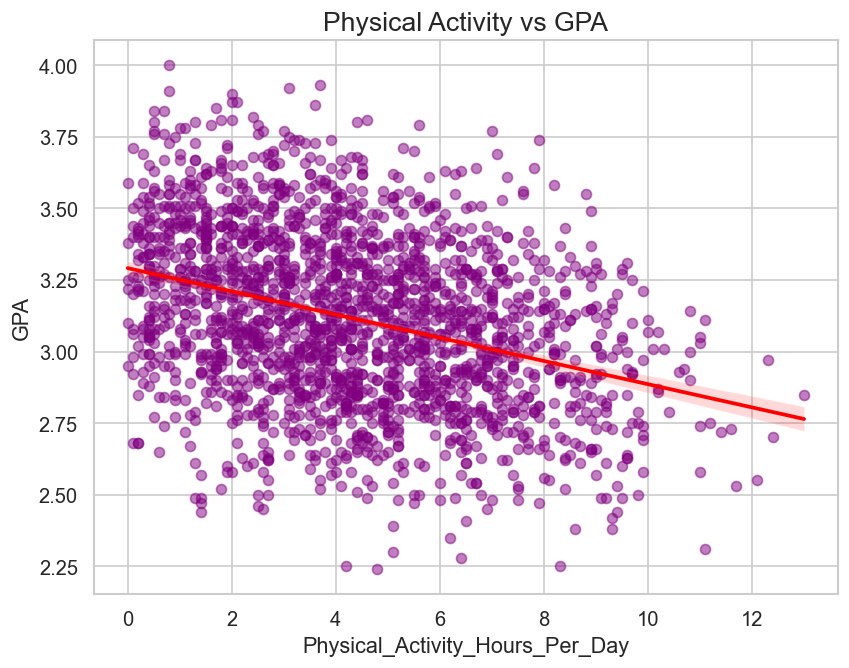

In [72]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=eda_df,
    x='Physical_Activity_Hours_Per_Day',
    y='GPA',
    scatter_kws={'alpha':0.5,'color':'purple'},
    line_kws={'color':'red'}
)

plt.title("Physical Activity vs GPA")

plt.show()

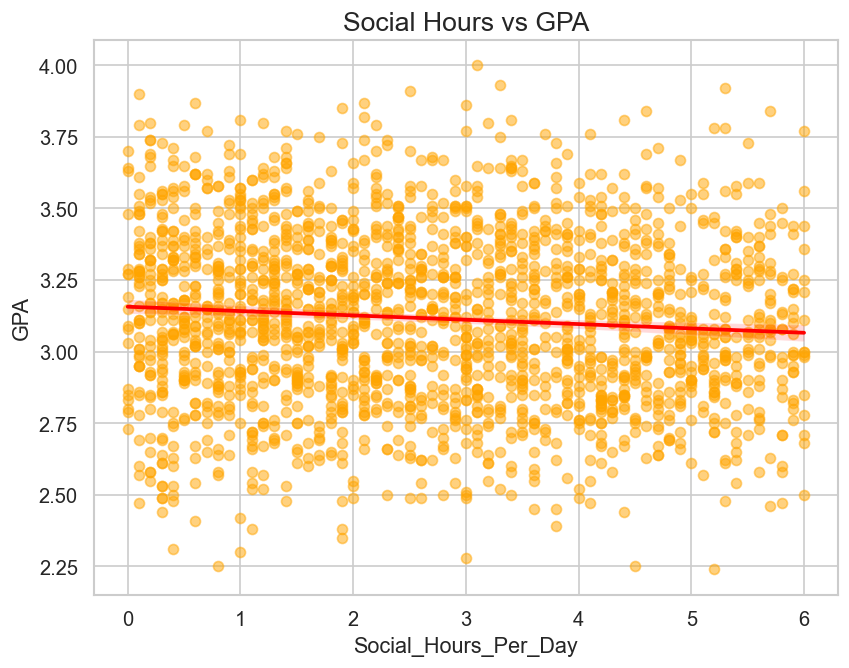

In [73]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=eda_df,
    x='Social_Hours_Per_Day',
    y='GPA',
    scatter_kws={'alpha':0.5,'color':'orange'},
    line_kws={'color':'red'}
)

plt.title("Social Hours vs GPA")

plt.show()

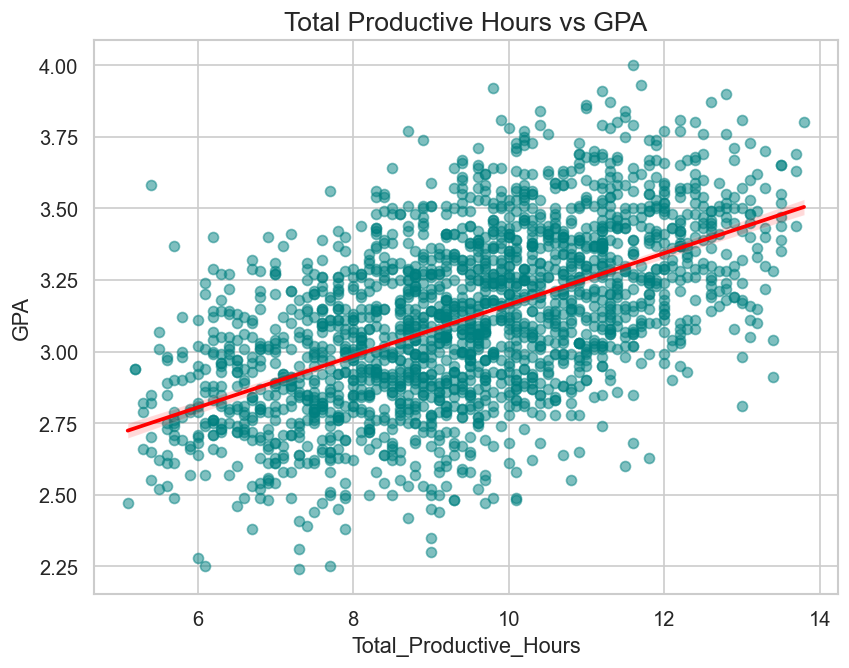

In [81]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="Total_Productive_Hours",
    y="GPA",
    scatter_kws={"alpha":0.5,"color":"teal"},
    line_kws={"color":"red"}
)

plt.title("Total Productive Hours vs GPA")

plt.show()

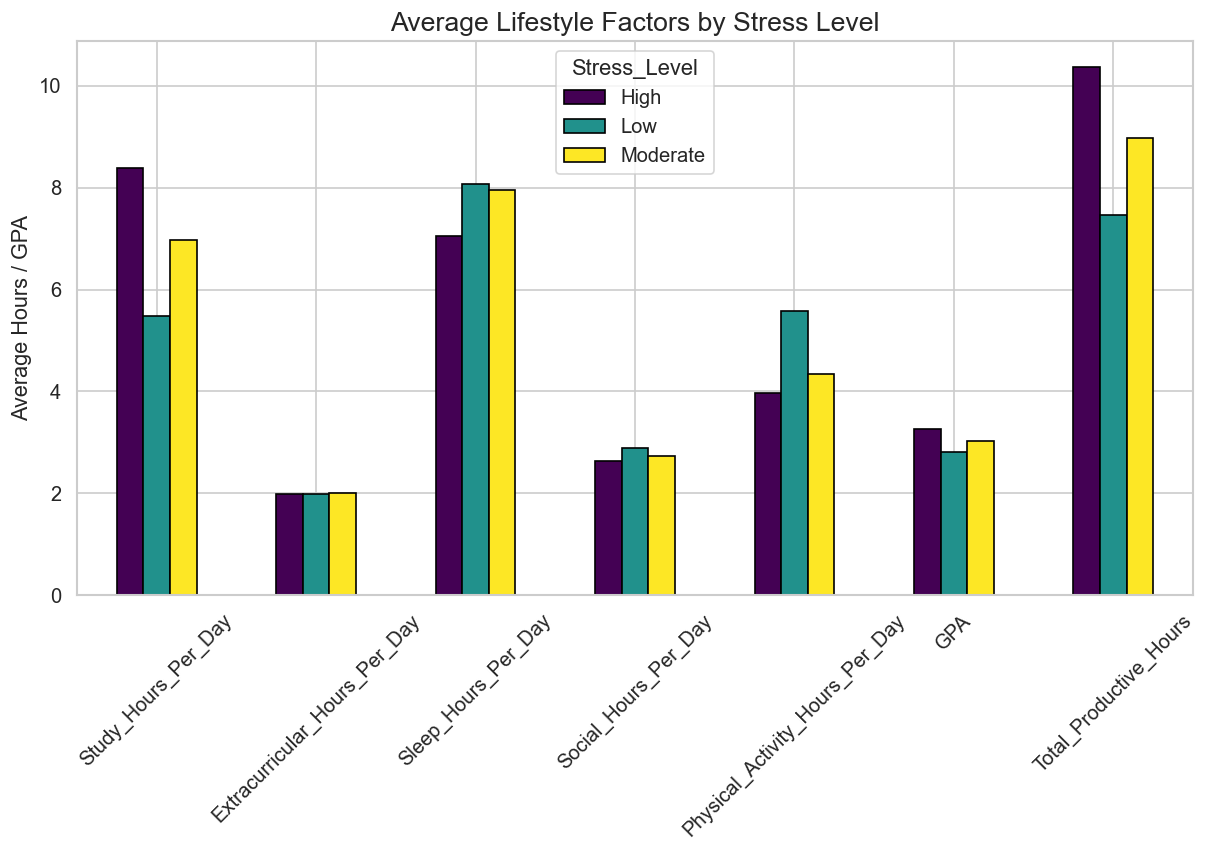

In [82]:
group = eda_df.groupby("Stress_Level").mean(numeric_only=True)

group.T.plot(
    kind='bar',
    figsize=(12,6),
    colormap='viridis',
    edgecolor='black'
)

plt.title("Average Lifestyle Factors by Stress Level")

plt.ylabel("Average Hours / GPA")

plt.xticks(rotation=45)

plt.show()

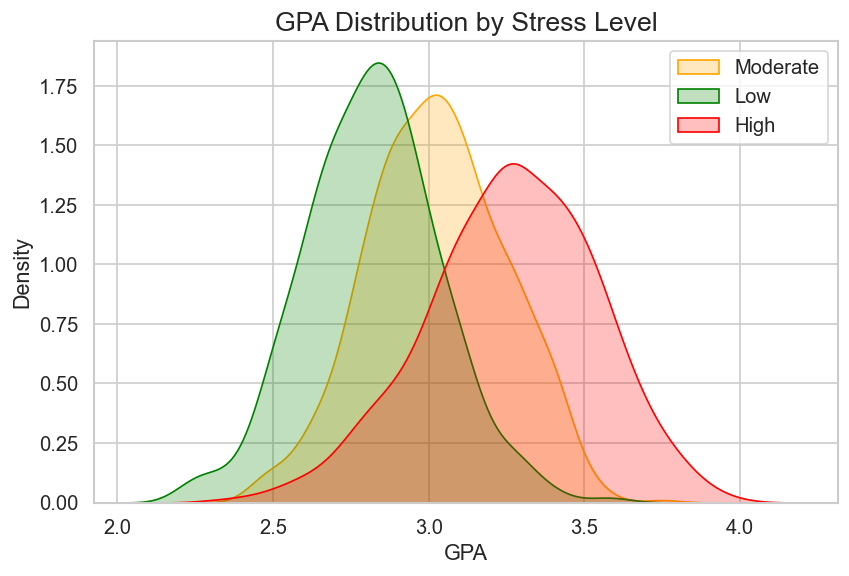

In [83]:
plt.figure(figsize=(8,5))

palette = {
    'High':'red',
    'Moderate':'orange',
    'Low':'green'
}

for level in eda_df['Stress_Level'].unique():

    sns.kdeplot(
        eda_df[eda_df['Stress_Level']==level]['GPA'],
        fill=True,
        label=level,
        color=palette[level]
    )

plt.title("GPA Distribution by Stress Level")

plt.legend()

plt.show()

In [87]:
corr = eda_df[numeric_cols].corr()

corr

,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Total_Productive_Hours
Study_Hours_Per_Day,1.000000,-0.002629,0.026717,-0.137820,-0.488113,0.734468,0.775737
Extracurricular_Hours_Per_Day,-0.002629,1.000000,0.008844,-0.139081,-0.369989,-0.032174,0.629015
Sleep_Hours_Per_Day,0.026717,0.008844,1.000000,-0.193556,-0.470302,-0.004278,0.026351
Social_Hours_Per_Day,-0.137820,-0.139081,-0.193556,1.000000,-0.417142,-0.085677,-0.194909
Physical_Activity_Hours_Per_Day,-0.488113,-0.369989,-0.470302,-0.417142,1.000000,-0.341152,-0.612942
GPA,0.734468,-0.032174,-0.004278,-0.085677,-0.341152,1.000000,0.550669
Total_Productive_Hours,0.775737,0.629015,0.026351,-0.194909,-0.612942,0.550669,1.000000


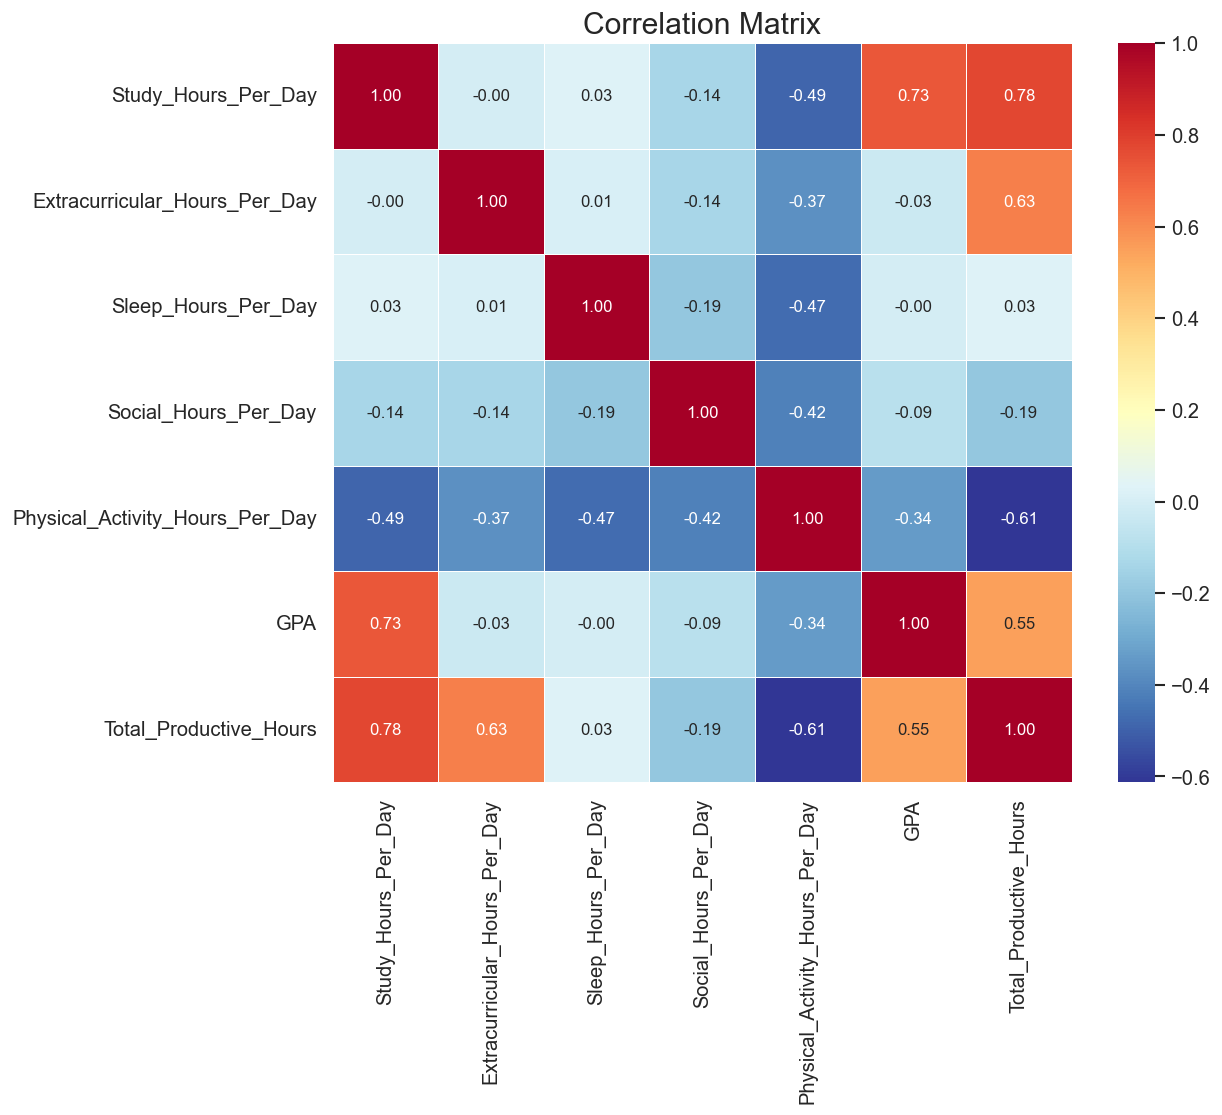

In [94]:
corr = eda_df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='RdYlBu_r',
    fmt=".2f",
    linewidths=.5,
    square=True,
    annot_kws={"size":10}
)

plt.title("Correlation Matrix", fontsize=18)

plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_21268\3096492277.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


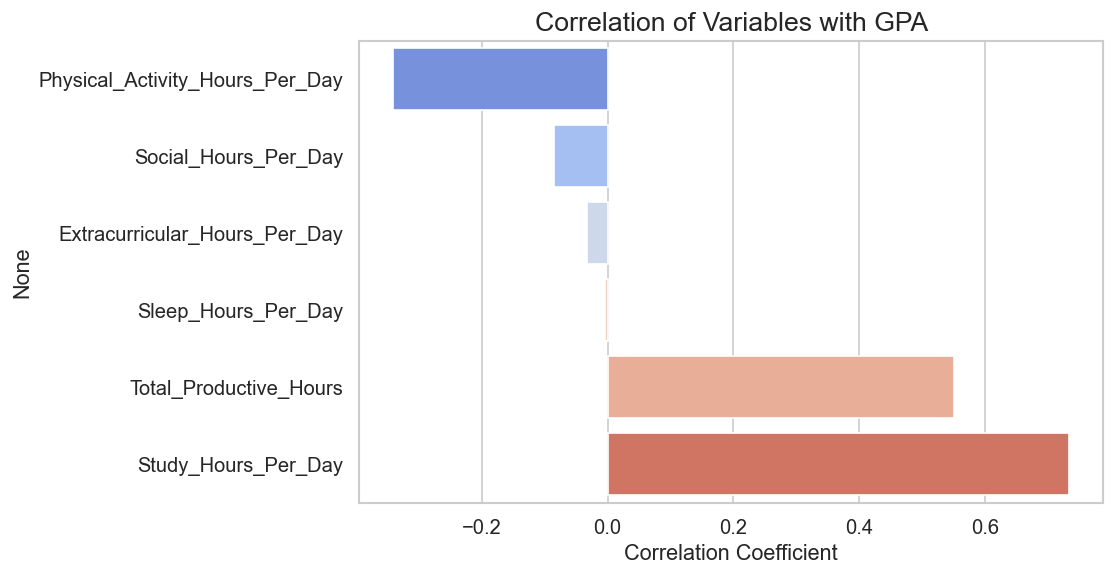

In [95]:
corr = eda_df.corr(numeric_only=True)

gpa_corr = corr["GPA"].drop("GPA").sort_values()

plt.figure(figsize=(8,5))

sns.barplot(
    x=gpa_corr.values,
    y=gpa_corr.index,
    palette="coolwarm"
)

plt.title("Correlation of Variables with GPA")

plt.xlabel("Correlation Coefficient")

plt.show()

In [96]:
from sklearn.linear_model import LinearRegression

X = df[[
    "Study_Hours_Per_Day",
    "Sleep_Hours_Per_Day",
    "Social_Hours_Per_Day",
    "Physical_Activity_Hours_Per_Day",
    "Extracurricular_Hours_Per_Day"
]]

y = df["GPA"]

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)

coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef

Intercept: 2.6968314304859966


,Feature,Coefficient
0,Study_Hours_Per_Day,0.125654
1,Sleep_Hours_Per_Day,-0.033279
2,Social_Hours_Per_Day,-0.027418
3,Physical_Activity_Hours_Per_Day,-0.028730
4,Extracurricular_Hours_Per_Day,-0.036227


In [98]:
from scipy.stats import f_oneway

high = df[df["Stress_Level"]=="High"]["GPA"]
moderate = df[df["Stress_Level"]=="Moderate"]["GPA"]
low = df[df["Stress_Level"]=="Low"]["GPA"]

F, p = f_oneway(high, moderate, low)

print("F Statistic:", F)
print("P-value:", p)

if p < 0.05:
    print("Significant difference in GPA among stress levels.")
else:
    print("No significant difference.")

F Statistic: 434.88819227855333
P-value: 1.6587091705299907e-157
Significant difference in GPA among stress levels.


In [99]:
from scipy.stats import ttest_ind

high = df[df["Stress_Level"]=="High"]["GPA"]
low = df[df["Stress_Level"]=="Low"]["GPA"]

t, p = ttest_ind(high, low)

print("T Statistic:", t)
print("P-value:", p)

if p < 0.05:
    print("High and Low stress students differ significantly in GPA.")
else:
    print("No significant difference.")

T Statistic: 25.71112257076905
P-value: 1.3882255321828482e-118
High and Low stress students differ significantly in GPA.


In [101]:
from scipy.stats import ttest_ind

high = df[df["Stress_Level"]=="High"]["Study_Hours_Per_Day"]
low = df[df["Stress_Level"]=="Low"]["Study_Hours_Per_Day"]

t, p = ttest_ind(high, low)

print("T Statistic:", t)
print("P-value:", p)

if p < 0.05:
    print("High and Low stress students differ significantly in Study Hours.")
else:
    print("No significant difference.")

T Statistic: 40.20221393298427
P-value: 1.2393141790395889e-231
High and Low stress students differ significantly in Study Hours.


In [102]:
df["GPA_Category"] = pd.cut(
    df["GPA"],
    bins=[2.2, 2.8, 3.3, 4.0],
    labels=["Low", "Medium", "High"]
)

from scipy.stats import chi2_contingency

table = pd.crosstab(
    df["Stress_Level"],
    df["GPA_Category"]
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("P-value:", p)

if p < 0.05:
    print("Significant association exists.")
else:
    print("No significant association.")

Chi-square: 561.5156743439861
P-value: 3.298348721706109e-120
Significant association exists.


In [103]:
df.groupby("Stress_Level")[[
    "Study_Hours_Per_Day",
    "Sleep_Hours_Per_Day",
    "Social_Hours_Per_Day",
    "Physical_Activity_Hours_Per_Day",
    "Extracurricular_Hours_Per_Day",
    "GPA"
]].agg(["mean", "std", "min", "max"])

Study_Hours_Per_Day                      Sleep_Hours_Per_Day  \
                            mean       std  min   max                mean   
Stress_Level                                                                
High                    8.385034  1.238311  5.0  10.0            7.046453   
Low                     5.474411  0.279753  5.0   5.9            8.063973   
Moderate                6.969585  0.597576  6.0   8.0            7.947626   

                                  Social_Hours_Per_Day            ...  \
                   std  min   max                 mean       std  ...   
Stress_Level                                                      ...   
High          1.552568  5.0  10.0             2.627794  1.687129  ...   
Low           1.205259  6.0  10.0             2.890909  1.673669  ...   
Moderate      1.167592  6.0  10.0             2.739614  1.692064  ...   

             Physical_Activity_Hours_Per_Day        \
                                         min   max   
Stress_Level                                         
High                                     0.0  13.0   
Low                                      0.1  12.4   
Moderate                                 0.0  11.0   

             Extracurricular_Hours_Per_Day                           GPA  \
                                      mean       std  min  max      mean   
Stress_Level                                                               
High                              1.979786  1.152370  0.0  4.0  3.261973   
Low                               1.988889  1.200075  0.0  4.0  2.816869   
Moderate                          2.006380  1.142807  0.0  4.0  3.024837   

                                    
                   std   min   max  
Stress_Level                        
High          0.274960  2.31  4.00  
Low           0.215396  2.24  3.58  
Moderate      0.220653  2.44  3.75  

[3 rows x 24 columns]

In [104]:
from scipy.stats import pearsonr

variables = [
    "Study_Hours_Per_Day",
    "Sleep_Hours_Per_Day",
    "Social_Hours_Per_Day",
    "Physical_Activity_Hours_Per_Day",
    "Extracurricular_Hours_Per_Day"
]

for var in variables:
    r, p = pearsonr(df[var], df["GPA"])

    print(f"{var}")
    print(f"Correlation: {r:.3f}")
    print(f"P-value: {p:.5f}")

    if p < 0.05:
        print("Significant relationship\n")
    else:
        print("No significant relationship\n")

Study_Hours_Per_Day
Correlation: 0.734
P-value: 0.00000
Significant relationship

Sleep_Hours_Per_Day
Correlation: -0.004
P-value: 0.84835
No significant relationship

Social_Hours_Per_Day
Correlation: -0.086
P-value: 0.00012
Significant relationship

Physical_Activity_Hours_Per_Day
Correlation: -0.341
P-value: 0.00000
Significant relationship

Extracurricular_Hours_Per_Day
Correlation: -0.032
P-value: 0.15034
No significant relationship

